In [1]:
from tensorflow import keras
import tensorflow as tf

from tensorflow.keras import models, layers #type: ignore
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

from tqdm import tqdm
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:
# Preparing the dataset and creating the features and target arrays

n_sims = 1000

x = []
y = []

for i in tqdm(range(n_sims), desc='Carregando dados', ascii=True):
    data = np.load(f'../input47/data_{i+1}.npy')
    x.append(data[:, :2])
    y.append(data[0, 2])  # equivalente a data[:, 2:][0][0]

x = np.array(x)
y = np.array(y)

norm = y.max()
# Normalização
# y /= y.max()


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.25)

Carregando dados:   0%|          | 0/1000 [00:00<?, ?it/s]

Carregando dados: 100%|##########| 1000/1000 [00:08<00:00, 120.42it/s]


In [5]:
early_stopping = keras.callbacks.EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # how many epochs to wait before stopping
    restore_best_weights=True,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',   
    patience=5,          
    verbose=1,          
    factor=0.75,          
    min_lr=0.0000001       
)

learning_rate_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,  # Initial learning rate for training
    decay_steps=100,            # Number of steps before decaying the learning rate
    decay_rate=0.5,              # Rate at which the learning rate decreases
)

lr_callback = keras.callbacks.LearningRateScheduler(learning_rate_schedule)


In [10]:
# defining the model

model = models.Sequential()

model.add(layers.Flatten())


model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(.01))
model.add(layers.Dense(16, activation='relu'))

model.add(layers.Dense(1))

model.compile(loss=keras.losses.MeanSquaredError(), optimizer='nadam', metrics=keras.metrics.MeanAbsoluteError())


history = model.fit(x_train, y_train, validation_split=.2, epochs=100, batch_size=8, verbose=1, callbacks=[reduce_lr])

Epoch 1/100
75/75 [==============================] - 1s 7ms/step - loss: 28.0487 - mean_absolute_error: 3.5579 - val_loss: 12.8319 - val_mean_absolute_error: 3.4923 - lr: 0.0010
Epoch 2/100
75/75 [==============================] - 0s 5ms/step - loss: 23.5279 - mean_absolute_error: 3.2139 - val_loss: 1.0059 - val_mean_absolute_error: 0.8336 - lr: 0.0010
Epoch 3/100
75/75 [==============================] - 0s 5ms/step - loss: 7.5174 - mean_absolute_error: 1.7703 - val_loss: 5.1410 - val_mean_absolute_error: 2.0856 - lr: 0.0010
Epoch 4/100
75/75 [==============================] - 0s 5ms/step - loss: 4.8694 - mean_absolute_error: 1.5278 - val_loss: 2.9800 - val_mean_absolute_error: 1.4847 - lr: 0.0010
Epoch 5/100
75/75 [==============================] - 0s 5ms/step - loss: 5.0410 - mean_absolute_error: 1.6039 - val_loss: 3.7345 - val_mean_absolute_error: 1.7295 - lr: 0.0010
Epoch 6/100
75/75 [==============================] - 0s 5ms/step - loss: 2.3457 - mean_absolute_error: 1.1211 - val_l

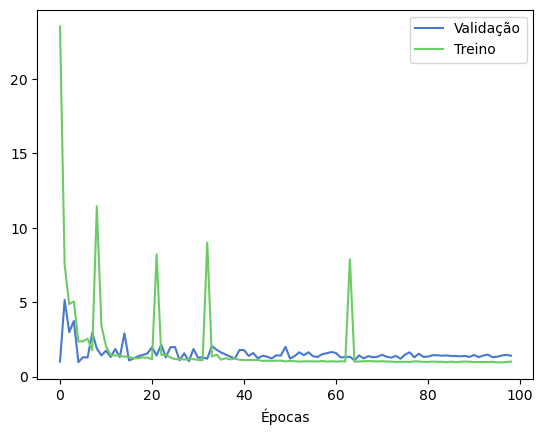

In [11]:
plt.plot(history.history['val_loss'][1:], label='Validação')
plt.plot(history.history['loss'][1:], label='Treino')


plt.xlabel('Épocas')
plt.legend()


# plt.savefig("imagens/loss_h0_dense")

plt.show()

In [12]:
y_pred = model.predict(x_test)


r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

mse

8/8 [==============================] - 0s 2ms/step


1.674911692443257

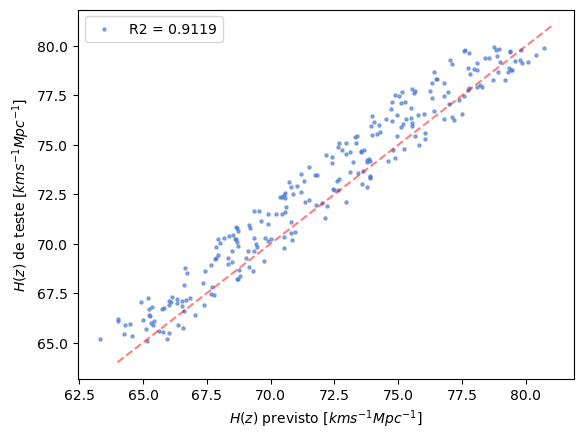

In [ ]:


plt.style.use('seaborn-v0_8-muted')

linha = np.linspace(64, 81)
# linha = np.linspace(.28, .35, 2500)


plt.scatter(y_pred, y_test, s=5, alpha=.6, label=f'R2 = {r2:.4f}')
plt.plot(linha, linha, alpha=.5, c='red', ls='--')

plt.legend()


plt.xlabel(r'$H (z)$ previsto [$km s^{-1} Mpc^{-1}$] ')
plt.ylabel(r'$H (z)$ de teste [$km s^{-1} Mpc^{-1}$] ')


# plt.savefig("imagens/metrics_h0_dense")
plt.show()




In [14]:
# forecasting "real" H(0)

real = np.load('../input47/data_real47.npy')
real = real[real[:, 1].argsort()]

real = real.reshape(-1,47,2)

In [25]:
real[:, :, 0][0]

array([0.12   , 0.07   , 0.09   , 0.1    , 0.2    , 0.179  , 0.1791 ,
       0.199  , 0.1993 , 0.35   , 0.4004 , 0.27   , 0.4783 , 0.44   ,
       0.35   , 0.3519 , 0.352  , 0.3802 , 0.17   , 0.4247 , 0.6    ,
       0.28   , 0.47   , 0.88   , 0.68   , 0.6797 , 0.44497, 0.4    ,
       0.57   , 0.48   , 0.73   , 0.5929 , 0.593  , 0.781  , 0.7812 ,
       0.9    , 0.875  , 0.8754 , 1.53   , 1.037  , 1.363  , 1.3    ,
       1.43   , 1.965  , 1.75   , 2.34   , 2.3    ])

In [15]:

final_real = model.predict(real, verbose=0)

In [19]:
final_real

array([[64.19892]], dtype=float32)

In [18]:
def mc_dropout_predict(model, X, n_iter=1000):
    """
    X shape: (batch_size, 80, 2) ou (batch_size, 160) se flatten
    """
    predictions = []
    for _ in range(n_iter):
        # Ativar dropout durante inferência
        pred = model(X, training=True).numpy()
        predictions.append(pred)
    
    predictions = np.array(predictions)
    mean = predictions.mean(axis=0)
    std = predictions.std(axis=0)
    
    return mean, std

# Exemplo para uma amostra
X_sample = real  # shape: (1, 80, 2)
mean, std = mc_dropout_predict(model, X_sample)
print(f"{mean[0][0]:.2f} ± {1.96*std[0][0]:.2f}")

64.78 ± 1.68
